### 개발 환경(OS) 및 라이브러리 버전

- OS: Windows 10
- Python: 3.12.1

- pandas: 2.2.3
- numpy: 2.0.1
- matplotlib: 3.9.2
- scikit-learn: 1.5.2
- xgboost: 2.1.3
- lightgbm: 4.5.0

---

XGB : 
'objective': 'reg:absoluteerror',
'eval_metric': 'mae',
'learning_rate': 0.024,
'max_depth': 8,
'subsample': 0.77,
'colsample_bytree': 1.0,
'seed': 42

LGB :
objective='regression_l1',
learning_rate=0.038,
max_depth=8,
num_leaves=64,
n_estimators=805,
colsample_bytree=0.99,
subsample=0.98,      
min_child_weight=1,
random_state=42

---

# 데이터 전처리

In [79]:
import pandas as pd
pd.options.display.max_columns = None

# 각 연도별 파일을 불러오기
data_2021 = pd.read_csv('data/2021_raw.csv', encoding='cp949')
data_2022 = pd.read_csv('data/2022_raw.csv', encoding='cp949')
data_2022 = data_2022.drop(data_2022.columns[0], axis=1)
data_2023 = pd.read_csv("data/2023_raw.csv", encoding = 'cp949')
data_2023 = data_2023.drop(data_2023.columns[[0, -1]], axis=1)
data_2024 = pd.read_csv('data/2024_raw.csv', encoding='cp949')

# 파일을 하나의 데이터프레임으로 병합
merged_data = pd.concat([data_2021, data_2022, data_2023, data_2024])
merged_data = merged_data.drop(columns=['승차권 종류'])
merged_data = merged_data.groupby(['BUSINESS_DAY', 'STATION_NO', '승ㆍ하차 구분'], observed=True, as_index=False).sum()
merged_data.rename(columns={'승ㆍ하차 구분': 'Board_Alight'}, inplace=True)
merged_data['Board_Alight'] = merged_data['Board_Alight'].map({'승차': 1, '하차': 2})

### 10, 11월 데이터 추가

In [5]:
import requests
import json
import pandas as pd
import xml.etree.ElementTree as ET
from urllib.parse import quote

your_api_key="uY%2BDjljcaCiYUCgm5DKfDuwT558a%2Fqn9%2B6yOiRuSSd0jy8rD8W1YGNzRG8UWfS2%2BJzojxZ5b05B0PScBJshBtQ%3D%3D"

In [ ]:
url="http://www.djtc.kr/OpenAPI/service/StationPassengerSVC/getStationPassenger?serviceKey=uY%2BDjljcaCiYUCgm5DKfDuwT558a%2Fqn9%2B6yOiRuSSd0jy8rD8W1YGNzRG8UWfS2%2BJzojxZ5b05B0PScBJshBtQ%3D%3D&startDate=20241201&endDate=20241201"

api_key=your_api_key

#encoded_api_key= quote("uY%2BDjljcaCiYUCgm5DKfDuwT558a%2Fqn9%2B6yOiRuSSd0jy8rD8W1YGNzRG8UWfS2%2BJzojxZ5b05B0PScBJshBtQ%3D%3D")

start_date='20241201'
end_date="20241201"

params={
    'serviceKey': api_key,
    'startDate': start_date,
    'endDate': end_date,
}

response= requests.get(url,params=params)
print(response.content)

b'<?xml version="1.0" encoding="UTF-8" standalone="yes"?><response><header><resultCode>00</resultCode><resultMsg>NORMAL SERVICE.</resultMsg></header><body><items><item><businessDay>20241201</businessDay><cnt_00>0</cnt_00><cnt_05>47</cnt_05><cnt_06>64</cnt_06><cnt_07>94</cnt_07><cnt_08>171</cnt_08><cnt_09>193</cnt_09><cnt_10>200</cnt_10><cnt_11>207</cnt_11><cnt_12>205</cnt_12><cnt_13>201</cnt_13><cnt_14>211</cnt_14><cnt_15>173</cnt_15><cnt_16>172</cnt_16><cnt_17>150</cnt_17><cnt_18>126</cnt_18><cnt_19>72</cnt_19><cnt_20>81</cnt_20><cnt_21>31</cnt_21><cnt_22>22</cnt_22><cnt_23>8</cnt_23><entryFlag>1</entryFlag><stationNo>101</stationNo><sumCnt>2428</sumCnt></item><item><businessDay>20241201</businessDay><cnt_00>24</cnt_00><cnt_05>13</cnt_05><cnt_06>35</cnt_06><cnt_07>46</cnt_07><cnt_08>85</cnt_08><cnt_09>71</cnt_09><cnt_10>116</cnt_10><cnt_11>75</cnt_11><cnt_12>97</cnt_12><cnt_13>150</cnt_13><cnt_14>190</cnt_14><cnt_15>177</cnt_15><cnt_16>179</cnt_16><cnt_17>262</cnt_17><cnt_18>166</cnt_

In [7]:
if response.status_code == 200:
    try:
        root= ET.fromstring(response.text)

        data=[]

        for item in root.findall('.//item'):
            row={
                'BUSINESS_DAY': item.find('businessDay').text if item.find
                ('businessDay') is not None else None,
                'STATION_NO': item.find('stationNo').text if item.find
                ('stationNo') is not None else None,
                'Board_Alight': item.find('entryFlag').text if item.find
                ('entryFlag') is not None else None,
                'TOTAL_CNT': item.find('sumCnt').text if item.find
                ('sumCnt') is not None else None,
                'CNT01': item.find('cnt_01').text if item.find('cnt_01') is 
                not None else None,
                'CNT02': item.find('cnt_02').text if item.find('cnt_02') is 
                not None else None,
                'CNT03': item.find('cnt_03').text if item.find('cnt_03') is 
                not None else None,
                'CNT04': item.find('cnt_04').text if item.find('cnt_04') is 
                not None else None,
                'CNT05': item.find('cnt_05').text if item.find('cnt_05') is 
                not None else None,
                'CNT06': item.find('cnt_06').text if item.find('cnt_06') is 
                not None else None,
                'CNT07': item.find('cnt_07').text if item.find('cnt_07') is 
                not None else None,
                'CNT08': item.find('cnt_08').text if item.find('cnt_08') is 
                not None else None,
                'CNT09': item.find('cnt_09').text if item.find('cnt_09') is 
                not None else None,
                'CNT10': item.find('cnt_10').text if item.find('cnt_10') is 
                not None else None,
                'CNT11': item.find('cnt_11').text if item.find('cnt_11') is 
                not None else None,
                'CNT12': item.find('cnt_12').text if item.find('cnt_12') is 
                not None else None,
                'CNT13': item.find('cnt_13').text if item.find('cnt_13') is 
                not None else None,
                'CNT14': item.find('cnt_14').text if item.find('cnt_14') is 
                not None else None,
                'CNT15': item.find('cnt_15').text if item.find('cnt_15') is 
                not None else None,
                'CNT16': item.find('cnt_16').text if item.find('cnt_16') is 
                not None else None,
                'CNT17': item.find('cnt_17').text if item.find('cnt_17') is 
                not None else None,
                'CNT18': item.find('cnt_18').text if item.find('cnt_18') is 
                not None else None,
                'CNT19': item.find('cnt_19').text if item.find('cnt_19') is 
                not None else None,
                'CNT20': item.find('cnt_20').text if item.find('cnt_20') is 
                not None else None,
                'CNT21': item.find('cnt_21').text if item.find('cnt_21') is 
                not None else None,
                'CNT22': item.find('cnt_22').text if item.find('cnt_22') is 
                not None else None,
                'CNT23': item.find('cnt_23').text if item.find('cnt_23') is 
                not None else None,
                'CNT00': item.find('cnt_00').text if item.find('cnt_00') is 
                not None else None
            }
            data.append(row)

        df=pd.DataFrame(data)

        df.fillna(0,inplace=True)
        df.to_csv("10_11month.csv",index=False,encoding='utf-8-sig')
        print(f"CSV 파일로 저장 완료:")
    except ET.ParseError as e:
        print("XML 파싱 중 오류 발생",e)
else:
    print(f"에러발생. 상태코드:{response.status_code}")
    print(response.text)


CSV 파일로 저장 완료:


C:\Users\USER\AppData\Local\Temp\ipykernel_62968\1866383547.py:70: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0,inplace=True)


In [8]:
import os

# 현재 작업 디렉토리 확인
current_dir = os.getcwd()
print(f"현재 파일이 저장된 경로: {current_dir}")


현재 파일이 저장된 경로: c:\Users\USER\OneDrive\바탕 화면\2-2 프로젝트\머신러닝 교내 공모전


In [83]:
data1011 = pd.read_csv("10_11month.csv")
data1011['STATION_NO'] = data1011['STATION_NO'] + 1000
merged_data = pd.concat([merged_data, data1011])

## 외부데이터
### 위도경도 데이터

In [84]:
# 데이터 생성
data_lalo = {
    "stationNo": [
        1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110,
        1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1120, 1121, 1122
    ],
    "stationNmKor": [
        "판암", "신흥", "대동", "대전", "중앙로", "중구청", "서대전네거리", "오룡", "용문", "탄방",
        "시청", "정부청사", "갈마", "월평", "갑천", "유성온천", "구암", "현충원", "월드컵경기장", "노은", "지족", "반석"
    ],
    "Latitude": [
        36.316896, 36.319652, 36.329532, 36.331582, 36.328664, 36.324831,
        36.322416, 36.328582, 36.338252, 36.345440, 36.351673, 36.357464,
        36.357522, 36.358272, 36.354578, 36.353689, 36.356605, 36.359021, 36.366825,
        36.374150, 36.384106, 36.392128
    ],
    "Longitude": [
        127.458264, 127.448791, 127.442848, 127.433117, 127.425842, 127.419627,
        127.412518, 127.405046, 127.393317, 127.384603, 127.386739, 127.381259,
        127.372632, 127.364382, 127.354467, 127.341524, 127.330830, 127.321525, 127.317859,
        127.317835, 127.319501, 127.314581
    ]
}

# 데이터프레임 생성
stations = pd.DataFrame(data_lalo)

station_data = merged_data.merge(stations, how='left', left_on='STATION_NO', right_on='stationNo')
station_data = station_data.drop(columns = ['stationNo'])

### 주변 상권 수 추가

In [85]:
import pandas as pd
import numpy as np

stores = pd.read_csv("data/소상공인병원 위경도(보건의료제외).csv", encoding="cp949")
stores.dropna(axis=1, inplace=True)

# 거리 계산을 위한 Haversine 함수 정의
def haversine(lat1, lon1, lat2, lon2):
    # 지구 반지름 (단위: km)
    R = 6371.0
    # 위도와 경도를 라디안으로 변환
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine 공식 적용
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 거리 임계값 (500미터, 0.5km)
distance_threshold = 0.4  # km

# 각 지하철 역에 대해 인근 점포 수 계산
station_store_counts = []

for _, station in stations.iterrows():
    # 지하철 역 좌표
    station_lat, station_lon = station['Latitude'], station['Longitude']
    
    # Haversine 공식을 사용해 모든 점포와의 거리 계산
    distances = haversine(station_lat, station_lon, stores['위도'].values, stores['경도'].values)
    
    # 거리 임계값 이내에 있는 점포 수 계산
    store_count = np.sum(distances < distance_threshold)
    
    # 결과 저장
    station_store_counts.append({
        'station_name': station['stationNmKor'],
        'store_count': store_count
    })

# 결과 데이터프레임으로 변환 및 출력
station_store_counts_df = pd.DataFrame(station_store_counts)

station_store_counts_df = station_store_counts_df.drop_duplicates()

station_store_counts_df.to_csv("station_store_counts_df.csv", index = False)

In [86]:
station_store_counts_df = pd.read_csv("station_store_counts_df.csv")

station_data_store = station_data.merge(station_store_counts_df, how='left', left_on='stationNmKor', right_on='station_name')
station_data_store['store_count'] = station_data_store['store_count'].astype(int)

### 주변 아파트 수, 추정거주인구 수 추가

In [87]:
import pandas as pd
pd.options.display.max_columns = None

# 데이터 유형을 지정하여 읽기
dtype_spec = {27: 'str'}  # 27번 열을 문자열로 지정
apt = pd.read_csv("data/apt_mst_info_202408.csv", encoding="cp949", dtype=dtype_spec)

apt = apt[['rdnmadr','nmhsh', 'lo','la']]

# "대전광역시"가 포함된 행만 필터링
daejeon_apt = apt[apt['rdnmadr'].str.contains("대전광역시", na=False)]

daejeon_apt = daejeon_apt.copy()

# 결측값 있는 행 확인
na_rows = daejeon_apt[daejeon_apt['nmhsh'].isna()]

# 특정 결측값 행 채우기
daejeon_apt.loc[na_rows.index, 'nmhsh'] = [55, 139, 1403, 1403, 348, 22, 235, 1306, 1254, 196, 61, 40]  # 적절한 값을 입력

daejeon_apt['nmhsh'] = daejeon_apt['nmhsh'].astype(int)

daejeon_apt = daejeon_apt.drop_duplicates(subset=['rdnmadr'])

In [88]:
import pandas as pd
import numpy as np

# 거리 계산을 위한 Haversine 함수 정의
def haversine(lat1, lon1, lat2, lon2):
    # 지구 반지름 (단위: km)
    R = 6371.0
    # 위도와 경도를 라디안으로 변환
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine 공식 적용
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 거리 임계값 (500미터, 0.5km)
distance_threshold = 0.4  # km

# 각 지하철 역에 대해 인근 아파트 세대수 합 계산
station_apartment_counts = []

for _, station in stations.iterrows():
    # 지하철 역 좌표
    station_lat, station_lon = station['Latitude'], station['Longitude']
    
    # Haversine 공식을 사용해 모든 아파트와의 거리 계산
    distances = haversine(station_lat, station_lon, daejeon_apt['la'].values, daejeon_apt['lo'].values)
    
    # 거리 임계값 이내에 있는 아파트 필터링
    nearby_apartments = daejeon_apt[distances < distance_threshold]
    
    # 세대수 합 계산
    total_households = nearby_apartments['nmhsh'].sum()
    
    # 결과 저장
    station_apartment_counts.append({
        'station_name': station['stationNmKor'],
        'apartment_count': len(nearby_apartments),  # 근처 아파트 수
        'total_households': total_households       # 근처 아파트 세대수 합
    })

# 결과 데이터프레임으로 변환 및 출력
station_apartment_counts_df = pd.DataFrame(station_apartment_counts)

station_apartment_counts_df = station_apartment_counts_df.drop_duplicates()

station_apartment_counts_df.to_csv("station_apt_counts_df.csv", index = False)

In [89]:
station_apartment_counts_df = pd.read_csv("station_apt_counts_df.csv")

station_data_store = station_data_store.merge(station_apartment_counts_df, how='left', left_on='stationNmKor', right_on='station_name')
station_data_store = station_data_store.drop(columns=['Latitude','Longitude','station_name_x','station_name_y'])
station_data_store['total_households'] = station_data_store['total_households'] * 2.4
station_data_store['total_households'] = station_data_store['total_households'].round().astype(int)

### 주변 주요시설(병원, 학교)

In [90]:
import pandas as pd
import numpy as np

school_data = pd.read_csv("data/전국초중등학교위치표준데이터.csv", encoding = 'cp949')
school_data = school_data[school_data['시도교육청명'] == '대전광역시교육청']
school_data = school_data[['학교명', '위도','경도']]

# Haversine 거리 계산 함수 정의
def haversine(lat1, lon1, lat2, lon2):
    # 지구 반지름 (단위: km)
    R = 6371.0
    # 위도와 경도를 라디안으로 변환
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine 공식 계산
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 거리 임계값 (0.4km)
distance_threshold = 0.4

# 각 지하철 역에 대해 0.4km 이내의 학교 수 계산
station_school_counts = []

for _, station in stations.iterrows():
    # 지하철 역 좌표
    station_lat, station_lon = station['Latitude'], station['Longitude']
    
    # 모든 학교와의 거리 계산
    distances = school_data.apply(
        lambda x: haversine(station_lat, station_lon, x['위도'], x['경도']),
        axis=1
    )
    
    # 거리 임계값 이내의 학교 필터링
    nearby_schools_count = (distances < distance_threshold).sum()
    
    # 결과 저장
    station_school_counts.append({
        'station_name': station['stationNmKor'],
        'nearby_school_count': nearby_schools_count
    })

# 결과 데이터프레임으로 변환 및 출력
station_school_counts_df = pd.DataFrame(station_school_counts)
station_school_counts_df = station_school_counts_df.drop_duplicates()

In [91]:
import pandas as pd
import numpy as np

# 지하철 역 데이터 불러오기
hospital_data = pd.read_csv("data/소상공인병원 위경도).csv", encoding = 'cp949')

# Haversine 거리 계산 함수 정의
def haversine(lat1, lon1, lat2, lon2):
    # 지구 반지름 (단위: km)
    R = 6371.0
    # 위도와 경도를 라디안으로 변환
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine 공식 계산
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 거리 임계값 (0.4km)
distance_threshold = 0.4

# 각 지하철 역에 대해 0.4km 이내의 학교 수 계산
station_hospital_counts = []

for _, station in stations.iterrows():
    # 지하철 역 좌표
    station_lat, station_lon = station['Latitude'], station['Longitude']
    
    # 모든 학교와의 거리 계산
    distances = hospital_data.apply(
        lambda x: haversine(station_lat, station_lon, x['위도'], x['경도']),
        axis=1
    )
    
    # 거리 임계값 이내의 학교 필터링
    nearby_hospital_count = (distances < distance_threshold).sum()
    
    # 결과 저장
    station_hospital_counts.append({
        'station_name': station['stationNmKor'],
        'nearby_hospital_count': nearby_hospital_count
    })

# 결과 데이터프레임으로 변환 및 출력
station_hospital_counts_df = pd.DataFrame(station_hospital_counts)
station_hospital_counts_df = station_hospital_counts_df.drop_duplicates()

In [92]:
nearby_facility_count = station_school_counts_df.merge(station_hospital_counts_df, how='left', on='station_name')
nearby_facility_count['nearby_facility_count'] = nearby_facility_count['nearby_school_count'] + nearby_facility_count['nearby_hospital_count']
nearby_facility_count = nearby_facility_count.drop(columns=['nearby_school_count','nearby_hospital_count'])

station_data_store = station_data_store.merge(nearby_facility_count, how = 'left', left_on = "stationNmKor", right_on = 'station_name')
station_data_store = station_data_store.drop(columns=["stationNmKor","station_name"])

### 대중교통 접근성(버스 환승)

In [93]:
import numpy as np

bus_station = pd.read_csv('data/국토교통부_전국 버스정류장 위치정보_20241028.csv', encoding = 'cp949')
bus_station = bus_station[bus_station['도시명'].str.contains('대전')]
bus_station = bus_station[['정류장명','위도','경도']]

# Haversine 거리 계산 함수
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # 지구 반지름(km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 400미터(0.4km) 임계값
distance_threshold = 0.4

# 각 지하철역에 대해 400m 이내의 정류장을 찾기
nearby_bus_stations = []

for _, station in stations.iterrows():
    station_lat, station_lon = station['Latitude'], station['Longitude']
    
    # Haversine 거리를 계산
    bus_station['Distance'] = haversine(
        station_lat, station_lon,
        bus_station['위도'].values, bus_station['경도'].values
    )
    
    # 임계값 이내의 정류장 필터링
    nearby_buses = bus_station[bus_station['Distance'] < distance_threshold]
    
    # 결과 저장
    for _, bus in nearby_buses.iterrows():
        nearby_bus_stations.append({
            'Station Name': station['stationNmKor'],
            'Bus Station Name': bus['정류장명'],
            'Distance (km)': bus['Distance']
        })

# 결과를 데이터프레임으로 정리
nearby_bus_stations_df = pd.DataFrame(nearby_bus_stations)

In [94]:
nearby_bus_stations_df = nearby_bus_stations_df.drop_duplicates()
nearby_bus_stations_df[nearby_bus_stations_df['Station Name'] == '중앙로']

,Station Name,Bus Station Name,Distance (km)
47,중앙로,으능정이거리,0.216631
48,중앙로,중앙로역6번출구,0.144633
49,중앙로,대흥동성당,0.317254
50,중앙로,대흥동성당,0.194509
51,중앙로,대전테크노파크,0.301467
52,중앙로,선화동우체국,0.204645
53,중앙로,중앙로역1번출구,0.081921
54,중앙로,중앙로역4번출구,0.182898
55,중앙로,중앙로역4번출구,0.095230
56,중앙로,중앙로역9번출구,0.076263


In [95]:
import pandas as pd
data1 = [
    {'STATION_NO': 1101, 'ROUTE_CNT': 17},
    {'STATION_NO': 1102, 'ROUTE_CNT': 12},
    {'STATION_NO': 1103, 'ROUTE_CNT': 17},
    {'STATION_NO': 1104, 'ROUTE_CNT': 37},
    {'STATION_NO': 1105, 'ROUTE_CNT': 48},
    {'STATION_NO': 1106, 'ROUTE_CNT': 25},
    {'STATION_NO': 1107, 'ROUTE_CNT': 22},
    {'STATION_NO': 1108, 'ROUTE_CNT': 12},
    {'STATION_NO': 1109, 'ROUTE_CNT': 11},
    {'STATION_NO': 1110, 'ROUTE_CNT': 13},
    {'STATION_NO': 1111, 'ROUTE_CNT': 15},
    {'STATION_NO': 1112, 'ROUTE_CNT': 22},
    {'STATION_NO': 1113, 'ROUTE_CNT': 11},
    {'STATION_NO': 1114, 'ROUTE_CNT': 8},
    {'STATION_NO': 1115, 'ROUTE_CNT': 11},
    {'STATION_NO': 1116, 'ROUTE_CNT': 28},
    {'STATION_NO': 1117, 'ROUTE_CNT': 17},
    {'STATION_NO': 1118, 'ROUTE_CNT': 10},
    {'STATION_NO': 1119, 'ROUTE_CNT': 7},
    {'STATION_NO': 1120, 'ROUTE_CNT': 6},
    {'STATION_NO': 1121, 'ROUTE_CNT': 8},
    {'STATION_NO': 1122, 'ROUTE_CNT': 17},
]

# 리스트를 데이터프레임으로 생성
route_cnt = pd.DataFrame(data1)

In [96]:
station_data_store = station_data_store.merge(route_cnt, how = 'left', on = "STATION_NO")

### 기온 데이터

In [97]:
temp_data = pd.read_csv("data/ta_20241130110937.csv", encoding='cp949', skiprows=7)
temp_data['날짜'] = temp_data['날짜'].str.strip()
temp_data['날짜'] = temp_data['날짜'].str.replace('-', '')
temp_data['average_temp'] = temp_data['평균기온(℃)']
temp_data['날짜'] = temp_data['날짜'].astype(int)
temp_data = temp_data.drop(columns=['지점','평균기온(℃)', '최저기온(℃)','최고기온(℃)'])
station_data_store = station_data_store.merge(temp_data, how = 'left', left_on = "BUSINESS_DAY", right_on = '날짜')
station_data_store = station_data_store.drop(columns=['날짜'])

## 내부데이터
### 출퇴근 시간대 혼잡도

In [98]:
station_data_store['BUSINESS_DAY'] = pd.to_datetime(station_data_store['BUSINESS_DAY'], format='%Y%m%d')
station_data_store['average_count'] = station_data_store[[f'CNT{str(i).zfill(2)}' for i in range(24)]].mean(axis=1)

station_data_store['CNT07_congestion'] = station_data_store['CNT07'] / station_data_store['average_count']
station_data_store['CNT08_congestion'] = station_data_store['CNT08'] / station_data_store['average_count']
station_data_store['CNT09_congestion'] = station_data_store['CNT09'] / station_data_store['average_count']
station_data_store['CNT17_congestion'] = station_data_store['CNT17'] / station_data_store['average_count']
station_data_store['CNT18_congestion'] = station_data_store['CNT18'] / station_data_store['average_count']
station_data_store['CNT19_congestion'] = station_data_store['CNT19'] / station_data_store['average_count']

station_data = station_data_store.drop(columns=['average_count'])

In [99]:
columns_to_zero = ['CNT01', 'CNT02', 'CNT03', 'CNT04']
station_data[columns_to_zero] = 0

### 날짜 데이터

In [100]:
station_data['BUSINESS_DAY'] = pd.to_datetime(station_data['BUSINESS_DAY'], format='%Y-%m-%d')
station_data['YEAR'] = station_data['BUSINESS_DAY'].dt.year
station_data['MONTH'] = station_data['BUSINESS_DAY'].dt.month
station_data['weekday'] = station_data['BUSINESS_DAY'].dt.weekday

### 상위 시간대 평균 초과 여부

In [101]:
# 시간대 열 리스트 (CNT01~CNT04 제외)
time_slots = [f'CNT{str(i).zfill(2)}' for i in range(24) if i not in range(1, 5)]

# 시간대별 평균 계산 (CNT01~CNT04 제외)
average_counts = station_data[time_slots].mean()

# 상위 6개 시간대 선택
top_6_slots = average_counts.sort_values(ascending=False).head(6).index # 승차량이 많은 시간대 5개
high_volume_top_6 = average_counts.index.isin(top_6_slots).astype(int) 

# 상위 6개 시간대의 평균값 이상인 경우를 1로 설정
for slot in top_6_slots:
    station_data[f'dummy_{slot}'] = (station_data[slot] >= average_counts[slot]).astype(int)

In [102]:
station_data.to_csv("station_data_all.csv", index = False)

In [103]:
station_data

,BUSINESS_DAY,STATION_NO,Board_Alight,TOTAL_CNT,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,CNT08,CNT09,CNT10,CNT11,CNT12,CNT13,CNT14,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00,store_count,apartment_count,total_households,nearby_facility_count,ROUTE_CNT,average_temp,CNT07_congestion,CNT08_congestion,CNT09_congestion,CNT17_congestion,CNT18_congestion,CNT19_congestion,YEAR,MONTH,weekday,dummy_CNT18,dummy_CNT08,dummy_CNT17,dummy_CNT16,dummy_CNT15,dummy_CNT13
0,2021-01-01,1101,1,1211,0,0,0,0,37,35,53,73,75,61,84,88,114,93,87,85,93,77,41,46,28,21,17,3,219,8,10301,11,17,-4.6,1.050372,1.446738,1.486375,1.843105,1.526012,0.812552,2021,1,4,0,0,0,0,0,0
1,2021-01-01,1101,2,1225,0,0,0,0,8,17,34,43,49,47,58,71,72,73,102,98,107,77,97,72,87,70,32,11,219,8,10301,11,17,-4.6,0.666122,0.842449,0.960000,2.096327,1.508571,1.900408,2021,1,4,0,0,0,0,0,0
2,2021-01-01,1102,1,464,0,0,0,0,11,16,14,28,37,26,37,27,48,29,31,34,34,28,13,19,21,9,2,0,110,1,1730,0,12,-4.6,0.724138,1.448276,1.913793,1.758621,1.448276,0.672414,2021,1,4,0,0,0,0,0,0
3,2021-01-01,1102,2,451,0,0,0,0,1,8,13,14,17,17,20,28,26,38,25,37,32,31,34,29,38,22,19,2,110,1,1730,0,12,-4.6,0.691796,0.745011,0.904656,1.702882,1.649667,1.809313,2021,1,4,0,0,0,0,0,0
4,2021-01-01,1103,1,1142,0,0,0,0,24,25,37,66,88,73,69,63,95,60,107,97,80,71,44,57,40,27,19,0,378,4,4925,11,17,-4.6,0.777583,1.387040,1.849387,1.681261,1.492119,0.924694,2021,1,4,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62871,2024-11-29,1120,2,5163,0,0,0,0,12,40,157,330,329,175,204,251,323,329,320,413,469,690,346,233,208,188,129,17,868,8,8832,14,6,2.2,0.729808,1.533992,1.529343,2.180128,3.207438,1.608367,2024,11,4,1,0,1,1,1,1
62872,2024-11-29,1121,1,2735,0,0,0,0,35,63,153,257,150,107,108,177,120,146,184,197,255,497,111,71,55,21,28,0,192,4,1798,4,8,2.2,1.342596,2.255210,1.316271,2.237660,4.361243,0.974040,2024,11,4,1,0,0,0,0,0
62873,2024-11-29,1121,2,2599,0,0,0,0,17,43,141,631,150,79,97,95,97,110,122,127,202,208,114,87,92,103,70,14,192,4,1798,4,8,2.2,1.302039,5.826856,1.385148,1.865333,1.920739,1.052713,2024,11,4,0,1,0,0,0,0
62874,2024-11-29,1122,1,8677,0,0,0,0,78,186,847,1137,578,394,339,434,444,348,425,527,712,979,404,266,241,246,90,0,488,2,2827,9,17,2.2,2.343285,3.145591,1.599078,1.969798,2.708473,1.117695,2024,11,4,1,1,1,1,1,1


----

# EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
pd.options.display.max_columns = None
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams['axes.unicode_minus'] = False

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv("station_data_all.csv")

# 예측 변수 선택 (CNT01 ~ CNT23, CNT00)
predictors = [f'CNT{str(i).zfill(2)}' for i in range(1, 24)] + ['CNT00']
predictor_data = data[predictors]

# 히스토그램 시각화
predictor_data.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'station_data_all.csv'

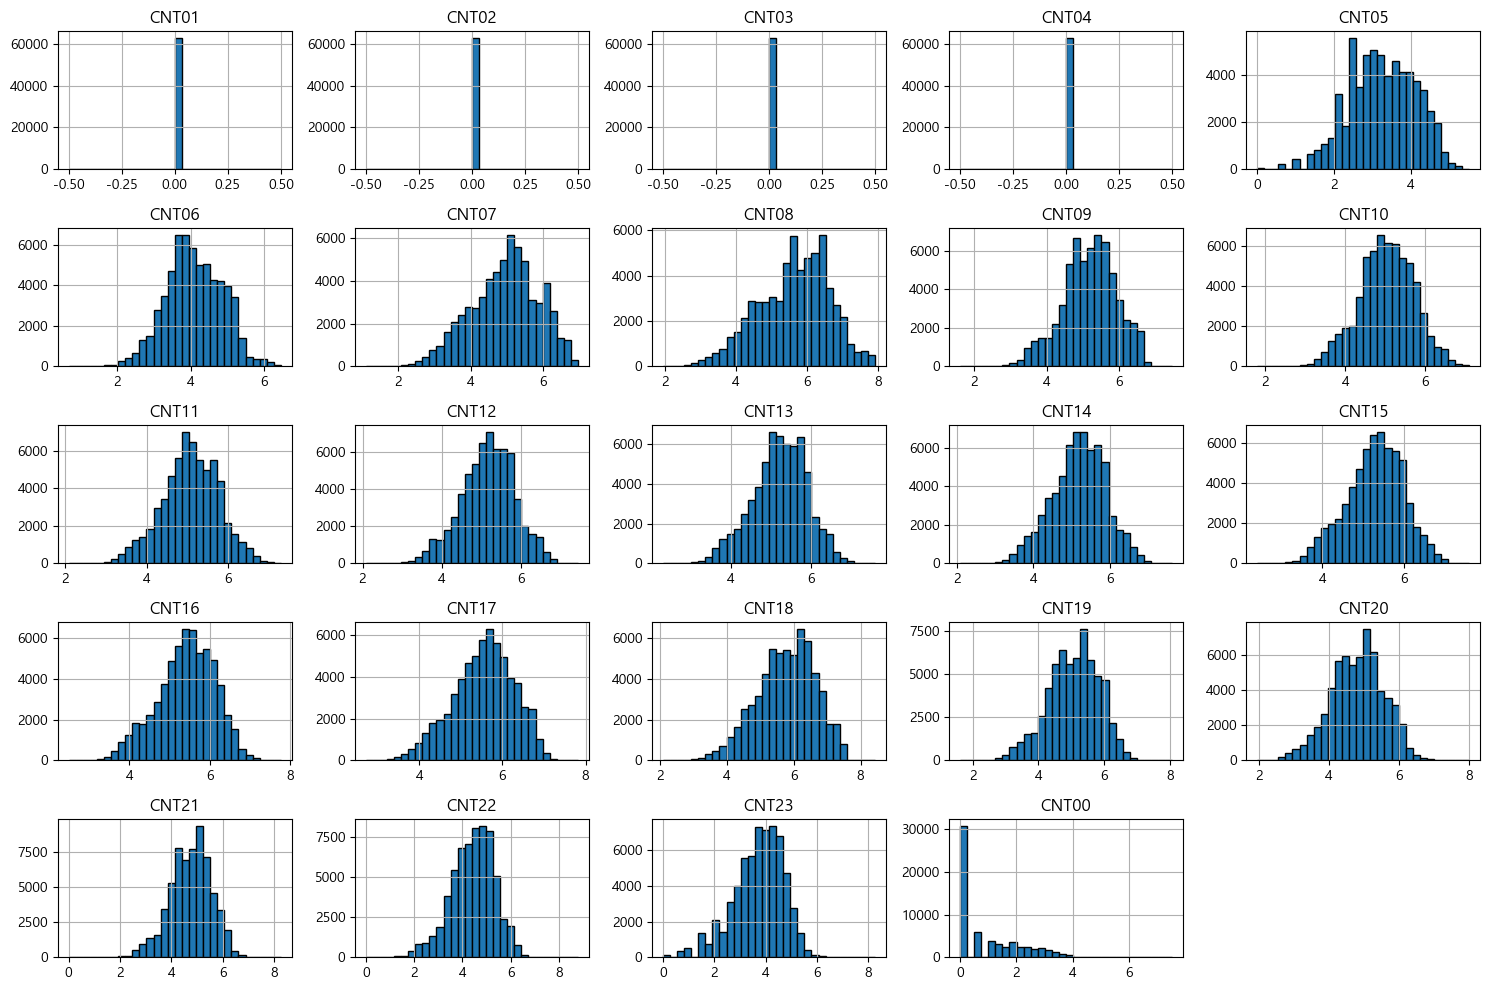

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 로그 변환 적용 (CNT01 ~ CNT23, CNT00)
predictor_data_log = np.log1p(predictor_data)  # np.log1p는 log(x + 1)을 계산

# 로그 변환된 데이터 분포 확인
predictor_data_log.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()


### 각 역의 시간대별 승차와 하차 패턴

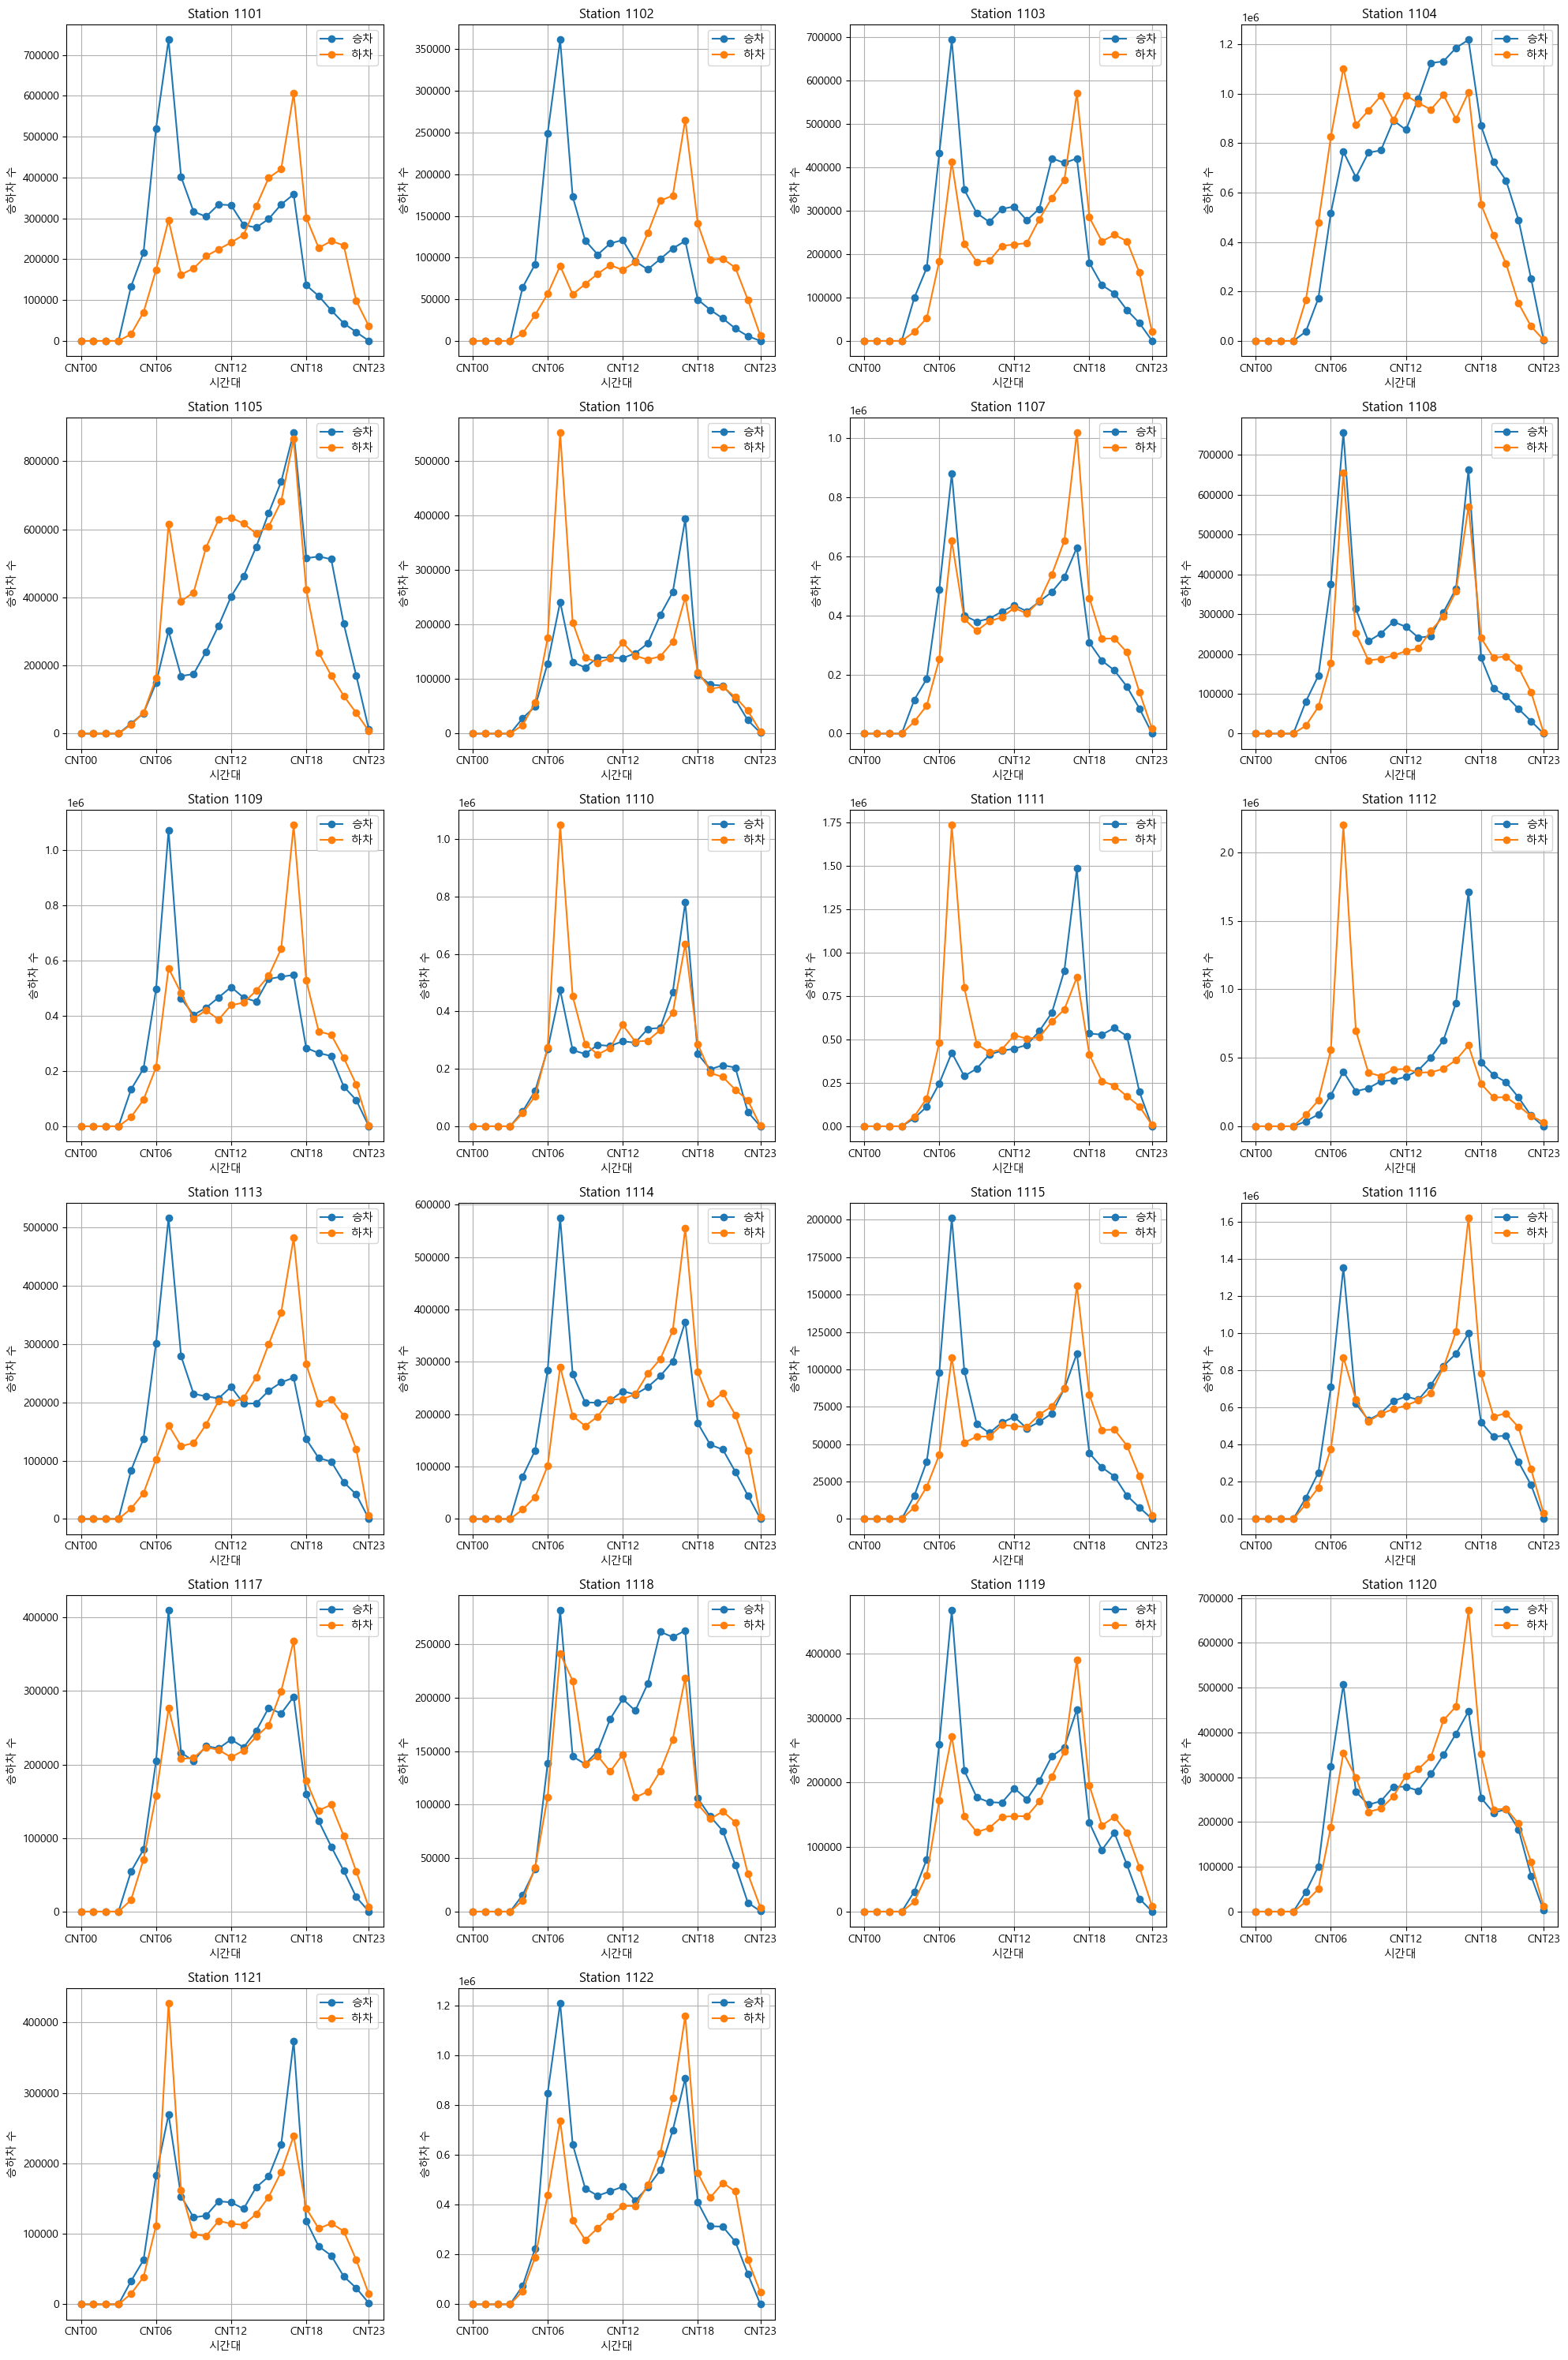

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

boarding_data = data[data['Board_Alight'] == 1]
alighting_data = data[data['Board_Alight'] == 2]

# 역 ID 및 시간대 설정
station_ids = range(1101, 1123)  # STATION_NO 범위
time_slots = [f'CNT{str(i).zfill(2)}' for i in range(1, 24)] + ['CNT00']  # CNT00 ~ CNT23

# 승차 및 하차 데이터 재구성 (누락된 역 ID 포함 처리)
boarding_hourly = boarding_data.groupby('STATION_NO')[time_slots].sum().reindex(station_ids, fill_value=0)
alighting_hourly = alighting_data.groupby('STATION_NO')[time_slots].sum().reindex(station_ids, fill_value=0)

# 플롯 생성
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 30))
axes = axes.flatten()

# 시간대 레이블 설정
time_labels = ['CNT00', 'CNT06', 'CNT12', 'CNT18', 'CNT23']  # 원하는 시간대 레이블
time_indices = [0, 6, 12, 18, 23]  # 해당하는 인덱스

for idx, station_id in enumerate(station_ids):
    if station_id in boarding_hourly.index and station_id in alighting_hourly.index:
        boarding_pattern = boarding_hourly.loc[station_id, time_slots]
        alighting_pattern = alighting_hourly.loc[station_id, time_slots]

        ax = axes[idx]
        ax.plot(range(24), boarding_pattern.values, label='승차', marker='o')
        ax.plot(range(24), alighting_pattern.values, label='하차', marker='o')
        ax.set_title(f'Station {station_id}')
        ax.set_xlabel('시간대')
        ax.set_ylabel('승하차 수')
        ax.grid(True)
        ax.legend()

        # X축 시간대 레이블 설정
        ax.set_xticks(time_indices)
        ax.set_xticklabels(time_labels)

# 남는 서브플롯 제거
for j in range(len(station_ids), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 주중과 주말의 시간대별 평균 승차량

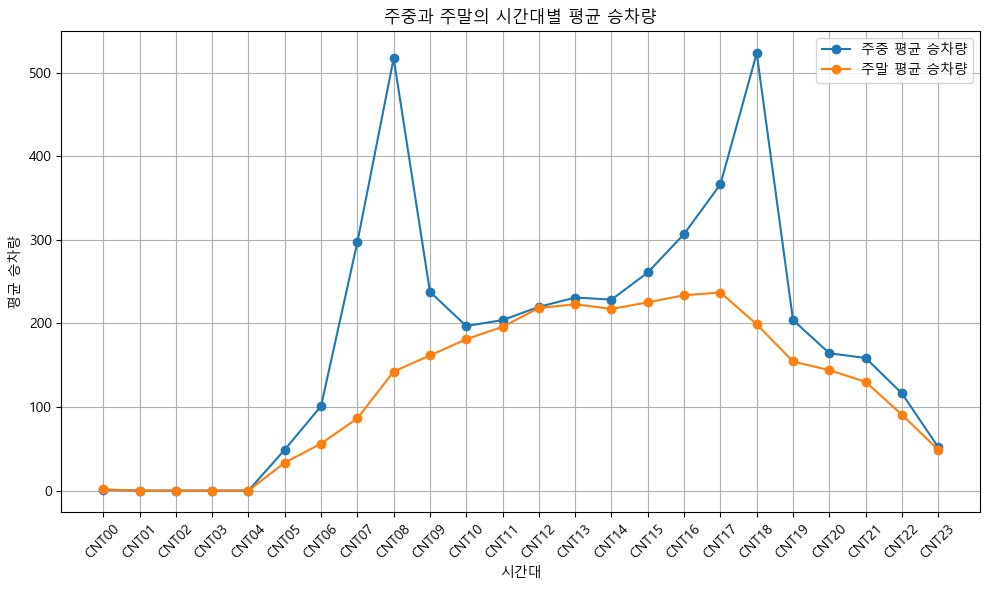

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

data = data[data['Board_Alight'] == 1]

# 데이터프레임 예시 (시간대 데이터는 CNT00 ~ CNT23)
# data['BUSINESS_DAY'] 컬럼과 시간대별 승차량 데이터가 있다고 가정
data['BUSINESS_DAY'] = pd.to_datetime(data['BUSINESS_DAY'])

# 주중/주말 구분 변수 생성
data['is_weekend'] = data['BUSINESS_DAY'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# 시간대별 열 리스트
time_slots = [f'CNT{str(i).zfill(2)}' for i in range(24)]

# 주중과 주말 시간대별 평균 계산
weekday_avg = data[data['is_weekend'] == 0][time_slots].mean()
weekend_avg = data[data['is_weekend'] == 1][time_slots].mean()

# 그래프 시각화 (X축 레이블을 CNT00 ~ CNT23으로 설정)
plt.figure(figsize=(10, 6))
plt.plot(range(24), weekday_avg, label='주중 평균 승차량', marker='o')
plt.plot(range(24), weekend_avg, label='주말 평균 승차량', marker='o')

# X축 레이블 변경
plt.title('주중과 주말의 시간대별 평균 승차량')
plt.xlabel('시간대')
plt.ylabel('평균 승차량')
plt.xticks(range(24), time_slots, rotation=45)  # X축 레이블을 CNT00 ~ CNT23으로 설정
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



### 년도별 승차량 분포

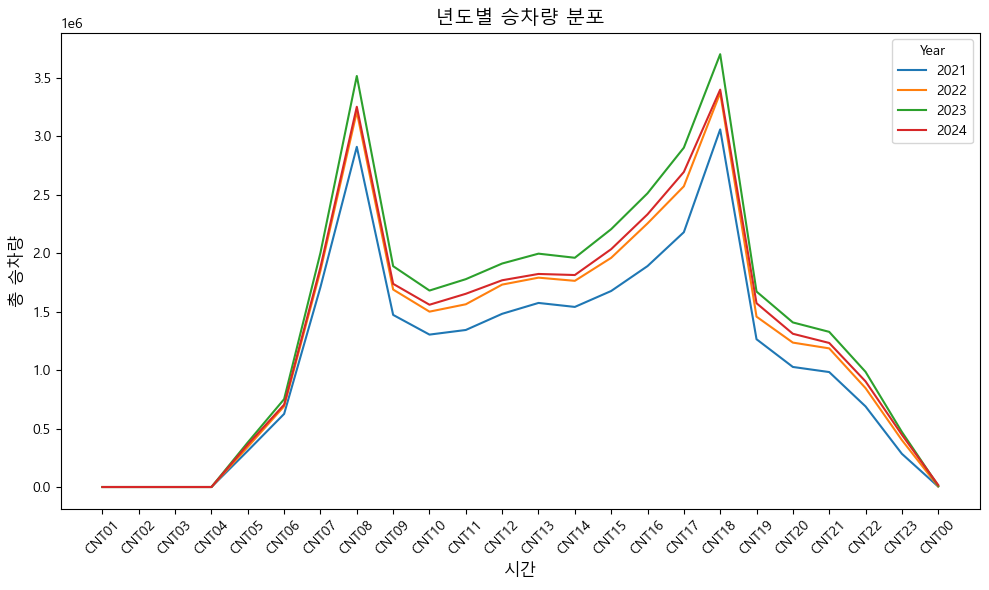

In [33]:
data['BUSINESS_DAY'] = pd.to_datetime(data['BUSINESS_DAY'], format='%Y-%m-%d')
data['YEAR'] = data['BUSINESS_DAY'].dt.year

hourly_columns = [f'CNT{str(i).zfill(2)}' for i in range(1, 24)] + ['CNT00']
data_hourly = data[['YEAR'] + hourly_columns]

hourly_counts_by_year = data_hourly.groupby('YEAR').sum()

plt.figure(figsize=(10, 6))
for year in hourly_counts_by_year.index:
    plt.plot(hourly_columns, hourly_counts_by_year.loc[year], label=f'{year}')

plt.title('년도별 승차량 분포', fontsize=14)
plt.xlabel('시간', fontsize=12)
plt.ylabel('총 승차량', fontsize=12)
plt.xticks(range(len(hourly_columns)), hourly_columns, rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()


### 토 일 승차량 비교

토요일 총 승차량: 15373430
일요일 총 승차량: 11379409


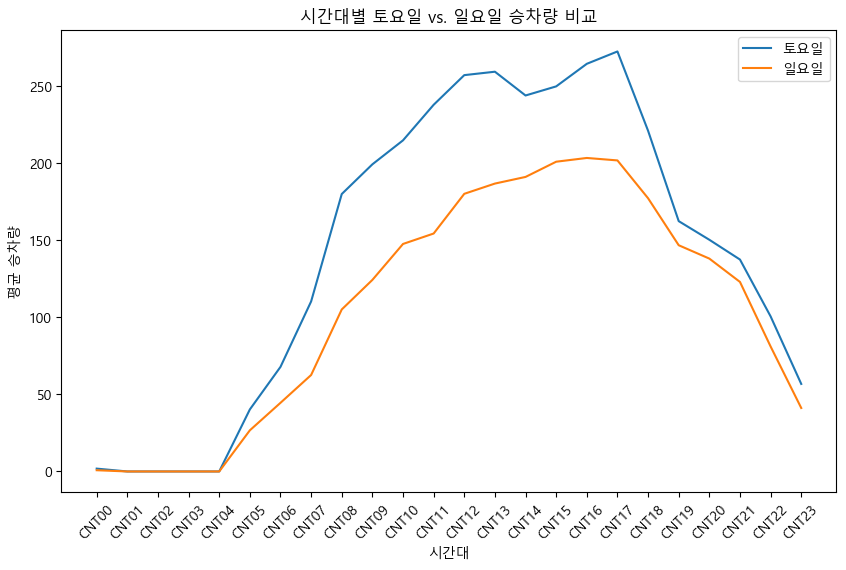

In [34]:
# BUSINESS_DAY를 날짜 형식으로 변환
data['BUSINESS_DAY'] = pd.to_datetime(data['BUSINESS_DAY'], format='%Y-%m-%d')

# 요일 정보 추가 (0: 월요일, ..., 6: 일요일)
data['weekday'] = data['BUSINESS_DAY'].dt.weekday

# 토요일(5)과 일요일(6) 데이터 필터링
saturday_data = data[data['weekday'] == 5]
sunday_data = data[data['weekday'] == 6]

# 1. 총 승차량 비교
saturday_total = saturday_data['TOTAL_CNT'].sum()
sunday_total = sunday_data['TOTAL_CNT'].sum()
print(f"토요일 총 승차량: {saturday_total}")
print(f"일요일 총 승차량: {sunday_total}")

# 2. 시간대별 평균 비교
time_columns = [f"CNT{str(i).zfill(2)}" for i in range(24)]  # CNT00~CNT23
saturday_means = saturday_data[time_columns].mean()
sunday_means = sunday_data[time_columns].mean()

# 3. 시간대별 승차량 시각화
plt.figure(figsize=(10, 6))
plt.plot(saturday_means, label='토요일')
plt.plot(sunday_means, label='일요일')
plt.xticks(range(24), [f"CNT{str(i).zfill(2)}" for i in range(24)], rotation=45)
plt.xlabel("시간대")
plt.ylabel("평균 승차량")
plt.title("시간대별 토요일 vs. 일요일 승차량 비교")
plt.legend()
plt.show()


----

# 모델링 - XGBoost + LightGBM

### XGB 모델링

In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 로드
data = pd.read_csv("C:\DATA\Training\station_data_all.csv")
data = data[data['Board_Alight'] == 1]

# BUSINESS_DAY를 날짜 형식으로 변환
data['BUSINESS_DAY'] = pd.to_datetime(data['BUSINESS_DAY'], format='%Y-%m-%d')

data['time_weight'] = data['YEAR'].apply(lambda x: 0.5 if x == 2021 else (0.75 if x == 2022 else (1.0 if x == 2023 else 1.2)))

# 날짜 단위로 데이터 분리
train_data = data[
    (data['BUSINESS_DAY'] >= '2021-01-01') & (data['BUSINESS_DAY'] <= '2024-08-31')
].copy()

valid_data = data[
    (data['BUSINESS_DAY'] >= '2024-09-01') & (data['BUSINESS_DAY'] <= '2024-11-30')
].copy()

# 입력 변수 및 타겟 선택
X_train = train_data.drop(columns=['BUSINESS_DAY', 'Board_Alight']).drop(train_data.columns[4:28], axis=1)
y_train = train_data.iloc[:, 4:28]  # CNT01 ~ CNT00

X_val = valid_data.drop(columns=['BUSINESS_DAY', 'Board_Alight']).drop(valid_data.columns[4:28], axis=1)
y_val = valid_data.iloc[:, 4:28]

# 로그 변환 (0 값 처리: 1을 더해서 변환)
y_train_log = np.log1p(y_train)  # 0 값 처리 (log(0+1))
y_val_log = np.log1p(y_val)

# XGBoost DMatrix 생성 (로그 변환된 타겟 사용)
dtrain = xgb.DMatrix(X_train, label=y_train_log.values, weight=train_data['time_weight'])
dvalid = xgb.DMatrix(X_val, label=y_val_log.values, weight=valid_data['time_weight'])

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
C:\Users\USER\AppData\Local\Temp\ipykernel_62968\2868682436.py:8: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("C:\DATA\Training\station_data_all.csv")


In [4]:
import random
from xgboost import XGBRegressor

model = XGBRegressor()

params = {
'objective': 'reg:absoluteerror',
'eval_metric': 'mae',
'learning_rate': 0.024,
'max_depth': 8,
'subsample': 0.77,
'colsample_bytree': 1.0,
'seed': 1233124
}

evals = [(dtrain, 'train'), (dvalid, 'eval')]
model = xgb.train(params, dtrain, num_boost_round=600, evals=evals, early_stopping_rounds=50)

preds = model.predict(dvalid)
xgb_preds = np.expm1(preds)

[0]	train-mae:1.74020	eval-mae:1.76658
[1]	train-mae:1.69878	eval-mae:1.72497
[2]	train-mae:1.65846	eval-mae:1.68440
[3]	train-mae:1.61907	eval-mae:1.64480
[4]	train-mae:1.58063	eval-mae:1.60615
[5]	train-mae:1.54315	eval-mae:1.56845
[6]	train-mae:1.50658	eval-mae:1.53160
[7]	train-mae:1.47090	eval-mae:1.49572
[8]	train-mae:1.43612	eval-mae:1.46071
[9]	train-mae:1.40221	eval-mae:1.42648
[10]	train-mae:1.36906	eval-mae:1.39310
[11]	train-mae:1.33680	eval-mae:1.36054
[12]	train-mae:1.30534	eval-mae:1.32877
[13]	train-mae:1.27462	eval-mae:1.29780
[14]	train-mae:1.24466	eval-mae:1.26759
[15]	train-mae:1.21546	eval-mae:1.23801


KeyboardInterrupt: 

In [3]:
# BUSINESS_DAY와 STATION_NO 정보 가져오기
valid_dates = valid_data['BUSINESS_DAY'].values
valid_stations = valid_data['STATION_NO'].values

# 예측값을 데이터프레임으로 변환
predictions_df = pd.DataFrame(
    xgb_preds, 
    columns=[f"CNT{str(i).zfill(2)}" for i in range(1, 24)] + ['CNT00']  # CNT01 ~ CNT24
)

# 소수점 반올림 및 정수형 변환
predictions_df = predictions_df.round(0).astype(int)

# BUSINESS_DAY와 STATION_NO 추가
predictions_df['BUSINESS_DAY'] = np.tile(valid_dates, (24, 1)).flatten()[:len(xgb_preds)]
predictions_df['STATION_NO'] = np.tile(valid_stations, (24, 1)).flatten()[:len(xgb_preds)]

# 컬럼 순서 재배열
predictions_df = predictions_df[[f"CNT{str(i).zfill(2)}" for i in range(1, 24)] + ['CNT00']]
predictions_df


,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,CNT08,CNT09,CNT10,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,0,0,0,0,56,91,99,209,193,203,...,161,165,169,133,93,69,50,23,13,0
1,0,0,0,0,26,36,34,83,75,65,...,53,50,56,65,35,26,19,9,3,0
2,0,0,0,0,47,58,78,163,173,192,...,148,142,177,121,84,65,47,31,22,0
3,0,0,0,0,21,147,232,300,361,527,...,1002,981,948,773,776,847,905,699,317,1
4,0,0,0,0,16,25,35,74,82,112,...,449,529,523,525,454,414,303,150,78,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1953,0,0,0,0,12,31,124,290,122,101,...,169,308,283,252,92,69,66,35,6,0
1954,0,0,0,0,24,72,270,492,178,132,...,151,192,214,266,93,74,73,38,13,0
1955,0,0,0,0,38,87,333,552,219,191,...,231,322,364,366,209,188,205,165,68,2
1956,0,0,0,0,29,56,185,255,117,104,...,146,170,250,514,125,76,73,38,24,1


In [4]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# 실제값 준비 (validation 데이터에서 CNT01 ~ CNT24)
y_true = valid_data.iloc[:, 4:28].values  # CNT01 ~ CNT24

# 예측값 준비 (predictions_df의 CNT01 ~ CNT24)
y_pred = predictions_df.values  # CNT01 ~ CNT24

# MAE 계산
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 9.49


### LGB 모델링

In [6]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 데이터 로드 및 전처리
data = pd.read_csv("C:\DATA\Training\station_data_all.csv")
data = data[data['Board_Alight'] == 1]

data['BUSINESS_DAY'] = pd.to_datetime(data['BUSINESS_DAY'], format='%Y-%m-%d')
data['time_weight'] = data['YEAR'].apply(lambda x: 0.5 if x == 2021 else (0.75 if x == 2022 else (1.0 if x == 2023 else 1.2)))

# 날짜 단위로 데이터 분리
train_data = data[
    (data['BUSINESS_DAY'] >= '2021-01-01') & (data['BUSINESS_DAY'] <= '2024-08-31')
].copy()

valid_data = data[
    (data['BUSINESS_DAY'] >= '2024-09-01') & (data['BUSINESS_DAY'] <= '2024-11-30')
].copy()

# 입력 변수 및 타겟 선택
X_train = train_data.drop(columns=['BUSINESS_DAY', 'Board_Alight']).drop(train_data.columns[4:28], axis=1)
X_val = valid_data.drop(columns=['BUSINESS_DAY', 'Board_Alight']).drop(valid_data.columns[4:28], axis=1)

y_train = train_data.iloc[:, 4:28]  # CNT01 ~ CNT24
y_val = valid_data.iloc[:, 4:28]

# 로그 변환 (0 값 처리: 1을 더해서 변환)
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

# LightGBM Dataset 생성 (가중치 추가)
dtrain = lgb.Dataset(X_train, label=y_train_log, weight=train_data['time_weight'])
dvalid = lgb.Dataset(X_val, label=y_val_log, weight=valid_data['time_weight'])

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
C:\Users\USER\AppData\Local\Temp\ipykernel_62188\4001162337.py:9: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("C:\DATA\Training\station_data_all.csv")


In [7]:
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

# LightGBM 모델 설정
lgb_model = lgb.LGBMRegressor(
    objective='regression_l1',  # MAE 기반
    learning_rate=0.038,
    max_depth=8,
    num_leaves=64,
    n_estimators=805,
    colsample_bytree=0.99,  # feature_fraction 대신 colsample_bytree 사용
    subsample=0.98,         # bagging_fraction 대신 subsample 사용
    min_child_weight=1,
    random_state=44
)

# MultiOutputRegressor를 사용해 다중 출력 회귀 설정
multi_output_model = MultiOutputRegressor(lgb_model)

# 모델 학습
multi_output_model.fit(X_train, y_train_log, sample_weight=train_data['time_weight'])

# 검증 데이터 예측
y_val_preds_log = multi_output_model.predict(X_val)
lgb_preds = np.expm1(y_val_preds_log)  # 로그 복원

# MAE 계산
mae = mean_absolute_error(y_val.values.flatten(), lgb_preds.flatten())
print(f"Validation MAE: {mae}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001854 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2188
[LightGBM] [Info] Number of data points in the train set: 29458, number of used features: 24
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped traini

In [8]:
predictions_df = pd.DataFrame(lgb_preds, columns=[f'CNT{str(i).zfill(2)}' for i in range(1, 24)] + ['CNT00'])
predictions_df = predictions_df.round(0).astype(int)
predictions_df

,CNT01,CNT02,CNT03,CNT04,CNT05,CNT06,CNT07,CNT08,CNT09,CNT10,...,CNT15,CNT16,CNT17,CNT18,CNT19,CNT20,CNT21,CNT22,CNT23,CNT00
0,0,0,0,0,57,81,99,209,190,201,...,168,165,170,132,93,65,49,24,13,0
1,0,0,0,0,25,34,33,85,76,68,...,50,49,55,61,34,26,18,9,4,0
2,0,0,0,0,48,61,78,162,175,187,...,150,145,175,120,83,63,48,31,21,0
3,0,0,0,0,19,150,229,316,340,506,...,956,951,924,758,751,866,873,689,283,2
4,0,0,0,0,16,24,35,76,83,117,...,441,539,528,527,458,421,310,151,77,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1953,0,0,0,0,11,30,125,287,121,100,...,170,308,282,253,91,71,65,36,6,0
1954,0,0,0,0,25,72,266,498,179,133,...,153,193,212,265,93,77,74,38,12,0
1955,0,0,0,0,37,85,325,555,221,191,...,233,317,364,364,205,192,196,165,69,2
1956,0,0,0,0,29,58,186,258,117,98,...,157,172,244,546,124,80,74,37,25,0


## 앙상블
### 단순평균

In [9]:
# 단순 평균 혼합
ensemble_preds = (xgb_preds + lgb_preds) / 2

# MAE 계산
ensemble_mae = mean_absolute_error(y_val, ensemble_preds)
print(f"Ensemble MAE: {ensemble_mae}")

Ensemble MAE: 9.296350560603925


### 가중평균

In [10]:
# 가중치 설정
weight_xgb = 0.7  # XGB 모델 가중치
weight_lgb = 0.3  # LGB 모델 가중치

# 가중평균 혼합
ensemble_preds_weighted = (weight_xgb * xgb_preds + weight_lgb * lgb_preds)

# MAE 계산
ensemble_mae_weighted = mean_absolute_error(y_val, ensemble_preds_weighted)
print(f"Weighted Ensemble MAE: {ensemble_mae_weighted}")


Weighted Ensemble MAE: 9.324035756158516


### 스태킹

In [11]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import numpy as np

# 1. XGB와 LGB 예측값 스택 생성
stacked_input = np.hstack([xgb_preds, lgb_preds])  # (n_samples, n_targets * 2)

# 2. 스태킹 메타 모델 초기화
# Ridge Regression 사용
meta_model = Ridge(alpha=1.0)

# 3. 메타 모델 학습
meta_model.fit(stacked_input, y_val)

# 4. 최종 예측
stacked_preds = meta_model.predict(stacked_input)

# 5. 성능 평가
stacked_mae = mean_absolute_error(y_val, stacked_preds)
print(f"Stacked Model MAE: {stacked_mae}")

Stacked Model MAE: 10.250480744011186


## 2024년 12월 1일 예측

In [12]:
import pandas as pd

data['BUSINESS_DAY'] = pd.to_datetime(data['BUSINESS_DAY'])
specific_dates = ['2024-11-10', '2024-11-17', '2024-11-24']
filtered_data_specific_dates = data[data['BUSINESS_DAY'].isin(pd.to_datetime(specific_dates))]

# 역 번호와 날짜 설정
stations = list(range(1101, 1123))  # 1101 ~ 1122
business_day = "20241201"
station_avg_total_cnt = filtered_data_specific_dates.groupby('STATION_NO')['TOTAL_CNT'].mean().values
store_count_list = filtered_data_specific_dates['store_count'].head(22).tolist()
apt_count = filtered_data_specific_dates['store_count'].head(22).tolist()
apt_population_list = filtered_data_specific_dates['total_households'].head(22).tolist()
nearby_facility_count_list = filtered_data_specific_dates['nearby_facility_count'].head(22).tolist()
ROUTE_CNT_list = filtered_data_specific_dates['ROUTE_CNT'].head(22).tolist()
average_temp_list = 5.5
station_avg_total_cnt7 = filtered_data_specific_dates.groupby('STATION_NO')['CNT07_congestion'].mean().values
station_avg_total_cnt8 = filtered_data_specific_dates.groupby('STATION_NO')['CNT08_congestion'].mean().values
station_avg_total_cnt9 = filtered_data_specific_dates.groupby('STATION_NO')['CNT09_congestion'].mean().values
station_avg_total_cnt17 = filtered_data_specific_dates.groupby('STATION_NO')['CNT17_congestion'].mean().values
station_avg_total_cnt18 = filtered_data_specific_dates.groupby('STATION_NO')['CNT18_congestion'].mean().values
station_avg_total_cnt19 = filtered_data_specific_dates.groupby('STATION_NO')['CNT19_congestion'].mean().values
year = 2024
month = 12
weekday = 6
dummy_18_list = [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
dummy_08_list = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
dummy_17_list = [0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
dummy_16_list = [0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
dummy_15_list = [0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
dummy_13_list = [0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
time_weight = 1.2

In [13]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb

# 1. 2024년 12월 1일 예측용 데이터 생성
future_data = pd.DataFrame({
    "BUSINESS_DAY": [business_day] * len(stations),
    "STATION_NO": stations,
    "TOTAL_CNT": station_avg_total_cnt,
    "store_count": store_count_list,
    "apartment_count" : apt_count,
    "total_households" : apt_population_list,
    "nearby_facility_count" : nearby_facility_count_list,
    'ROUTE_CNT' : ROUTE_CNT_list,
    "average_temp" : [average_temp_list] * len(stations),
    "CNT07_congestion": station_avg_total_cnt7, 
    "CNT08_congestion": station_avg_total_cnt8,
    "CNT09_congestion": station_avg_total_cnt9, 
    "CNT17_congestion": station_avg_total_cnt17, 
    "CNT18_congestion": station_avg_total_cnt18, 
    "CNT19_congestion": station_avg_total_cnt19,
    "YEAR": [year] * len(stations),
    "MONTH": [month] * len(stations),
    "weekday": [weekday] * len(stations),
    "dummy_CNT18" : dummy_18_list,
    "dummy_CNT08" : dummy_08_list,
    "dummy_CNT17" : dummy_17_list,
    "dummy_CNT16" : dummy_16_list,
    "dummy_CNT15" : dummy_15_list,
    "dummy_CNT13" : dummy_13_list,
    "time_weight": [time_weight] * len(stations),
})

# CNT01 ~ CNT23 + CNT00로 시간대 설정
time_columns = [f"CNT{str(i).zfill(2)}" for i in range(1, 24)] + ['CNT00']

# 학습 데이터의 특성 이름 가져오기 (XGBoost와 LightGBM 모두 동일한 feature 사용)
model_features = model.feature_names  # 학습 시 사용된 특성 이름
X_future = future_data[model_features]  # 예측용 데이터

# 2. XGBoost 예측 수행
dfuture_xgb = xgb.DMatrix(X_future)
preds_future_xgb_log = model.predict(dfuture_xgb)  # XGBoost 로그 변환된 예측값

# 3. LightGBM 예측 수행
# LightGBM 모델 불러오기
preds_future_lgb_log = multi_output_model.predict(X_future)  # LightGBM 로그 변환된 예측값

# 4. XGBoost와 LightGBM 예측값 평균
# 로그 변환된 값에서 평균을 계산
preds_future_log_combined = (preds_future_xgb_log + preds_future_lgb_log) / 2

# 5. 로그 역변환 (expm1 사용)
predictions_combined = np.expm1(preds_future_log_combined)  # 로그 역변환

# 6. 결과를 데이터프레임으로 변환
predictions_combined_df = pd.DataFrame(
    predictions_combined.reshape(len(stations), 24),  # 22개 역 x 24시간 기준으로 변환
    columns=[f"CNT{str(i).zfill(2)}" for i in range(1, 24)] + ['CNT00']  # 시간대 컬럼
)

# BUSINESS_DAY와 STATION_NO 추가
predictions_combined_df['BUSINESS_DAY'] = '20241201'
predictions_combined_df['STATION_NO'] = stations

# BUSINESS_DAY, STATION_NO 및 시간대 컬럼을 정확히 지정
predictions_combined_df = predictions_combined_df[['BUSINESS_DAY', 'STATION_NO'] + [f"CNT{str(i).zfill(2)}" for i in range(1, 24)] + ['CNT00']]

# 7. 소수점 반올림 및 정수형 변환
predictions_combined_df.iloc[:, 2:] = predictions_combined_df.iloc[:, 2:].round(0).astype(int)

# 8. 결과 저장
predictions_combined_df.to_csv('prediction.csv', index=False, float_format='%d')


---

## 변수중요도

### XGBoost

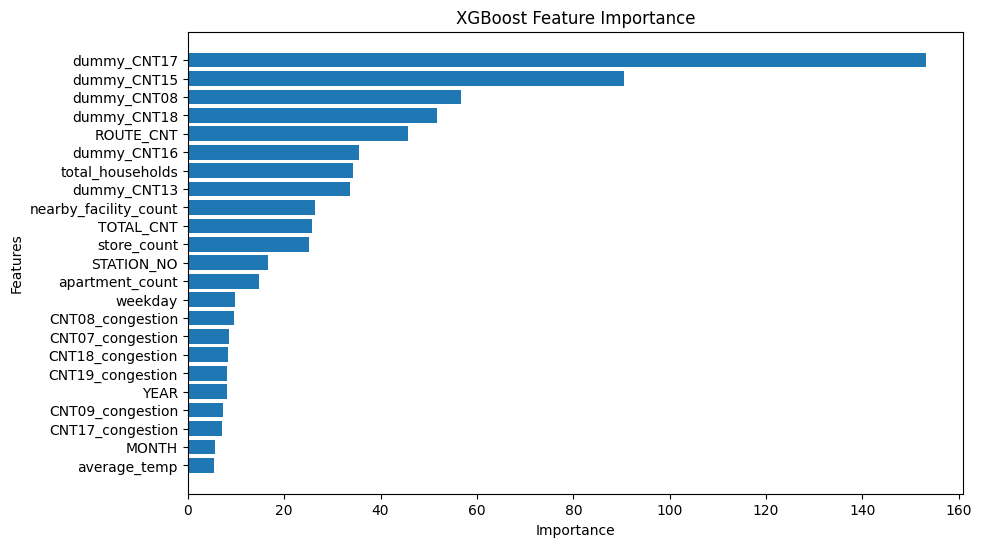

In [14]:
import matplotlib.pyplot as plt

# XGBoost 모델 변수 중요도 가져오기
xgb_importance = model.get_score(importance_type='gain')

# 중요도를 DataFrame으로 변환
xgb_importance_df = pd.DataFrame(
    list(xgb_importance.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(xgb_importance_df['Feature'], xgb_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.show()


### LightGBM

                  Feature  Gain Importance
1               TOTAL_CNT    312381.927156
21            dummy_CNT15     68285.332428
18            dummy_CNT08     66309.593149
22            dummy_CNT13     55556.249638
12       CNT18_congestion     51363.945823
9        CNT08_congestion     46919.163982
8        CNT07_congestion     45061.478506
19            dummy_CNT17     44499.806949
10       CNT09_congestion     40951.976704
13       CNT19_congestion     40468.387979
11       CNT17_congestion     37896.737921
7            average_temp     25395.201457
20            dummy_CNT16     22375.307763
2             store_count     21547.566263
4        total_households     20112.672579
5   nearby_facility_count     17780.773418
0              STATION_NO     15737.801191
16                weekday     14742.902547
6               ROUTE_CNT     14455.660005
14                   YEAR     13056.621430
15                  MONTH     10798.560875
3         apartment_count      6168.658396
17         

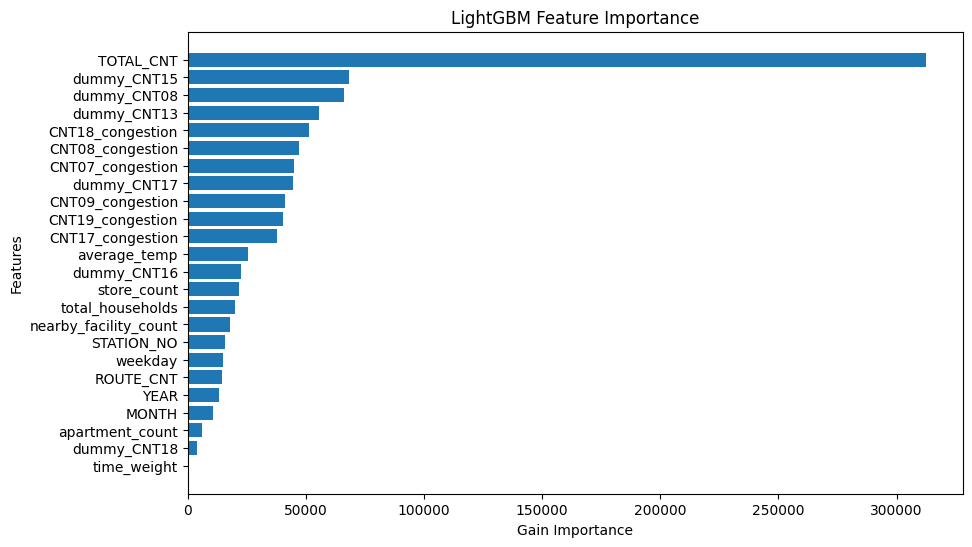

In [15]:
import numpy as np

# Split, Gain 중요도 초기화
gain_importances = np.zeros(len(model_features))

# 각 출력 변수에 대해 학습된 모델의 중요도를 합산
for estimator in multi_output_model.estimators_:
    gain_importances += estimator.booster_.feature_importance(importance_type='gain')

# 평균 중요도로 변환
gain_importances /= len(multi_output_model.estimators_)

# DataFrame으로 정리
lgb_importance_df = pd.DataFrame({
    'Feature': model_features,
    'Gain Importance': gain_importances
}).sort_values(by='Gain Importance', ascending=False)

# 중요도 출력
print(lgb_importance_df)

# Gain 기반 중요도 시각화
plt.figure(figsize=(10, 6))
plt.barh(lgb_importance_df['Feature'], lgb_importance_df['Gain Importance'])
plt.xlabel('Gain Importance')
plt.ylabel('Features')
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()
plt.show()


---

## 하이퍼파라미터 튜닝

### XGB - 랜덤서치 후 그리드 서치로 세밀하게 탐색

In [16]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import uniform, randint

# 랜덤 서치를 위한 하이퍼파라미터 범위 설정
param_distributions = {
    'learning_rate': uniform(0.01, 0.3),  # 학습률
    'max_depth': randint(3, 10),          # 트리 깊이
    'subsample': uniform(0.6, 0.4),       # 샘플링 비율
    'colsample_bytree': uniform(0.6, 0.4),  # 피처 샘플링 비율
    'n_estimators': randint(100, 1000)    # 부스팅 라운드 수
}

# 랜덤 서치 객체 설정
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(objective='reg:absoluteerror', eval_metric='mae', seed=42),
    param_distributions=param_distributions,
    n_iter=50,  # 랜덤 탐색 횟수
    scoring='neg_mean_absolute_error',
    cv=3,  # 교차 검증
    verbose=2,
    n_jobs=-1
)

# 랜덤 서치 실행
random_search.fit(X_train, y_train_log)

# 유망한 영역 출력
print("Best parameters from Random Search: ", random_search.best_params_)
print("Best MAE from Random Search: ", -random_search.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import random

param_grid = {
    'learning_rate': [0.02, 0.024, 0.03],  # 랜덤서치 값 중심으로
    'max_depth': [6, 7, 8],               # 범위를 좁게 설정
    'subsample': [0.75, 0.77, 0.8],       # 근처 값 포함
    'colsample_bytree': [0.9, 0.95, 1.0],      # 범위 좁게
    'n_estimators': [550, 600, 650]      # 트리 개수 조정
}

# XGBRegressor 모델 생성
model = XGBRegressor(objective='reg:absoluteerror', eval_metric='mae')

# GridSearchCV 설정
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',  # MAE를 최소화
    cv=3,                              # 3-폴드 교차 검증
    verbose=1,
    n_jobs=-1                          # 병렬 처리
)

# 데이터셋 (X_train, y_train)으로 학습
grid_search.fit(X_train, y_train)

print("최적의 파라미터:", grid_search.best_params_)
print("최적의 점수 (MAE):", -grid_search.best_score_)


### LGB - 랜덤서치로 하이퍼파라미터 튜닝

In [ ]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 랜덤 서치를 위한 파라미터 분포 정의
param_distributions = {
    'estimator__learning_rate': uniform(0.01, 0.1),  # MultiOutputRegressor 내부의 모델
    'estimator__max_depth': randint(3, 10),
    'estimator__num_leaves': randint(20, 50),
    'estimator__n_estimators': randint(100, 1000),
    'estimator__feature_fraction': uniform(0.7, 0.3),
    'estimator__bagging_fraction': uniform(0.7, 0.3),
    'estimator__min_child_weight': randint(1, 10)
}

# LightGBM 모델 설정 및 MultiOutputRegressor 래핑
base_lgb = lgb.LGBMRegressor(objective='regression_l1', random_state=42)
multi_lgb = MultiOutputRegressor(base_lgb)

# RandomizedSearchCV 설정
random_search = RandomizedSearchCV(
    estimator=multi_lgb,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# RandomizedSearchCV 실행
random_search.fit(X_train, y_train_log)

# 최적 파라미터 출력
print("Best Parameters:", random_search.best_params_)
print("Best MAE:", -random_search.best_score_)